# Basic WSSS pipeline

The first WSSS pipeline takes a very conventional approach to solving the WSSS problem. The architecture is as follows:
- DINOv3 produces patch tokens
- Linear probe classifies based on patch tokens, and also gets reused to create CAMs.
- DenseCRF refines edges to produce a cleaner mask

In [1]:
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

In [2]:
from dataset import make_voc_datasets, wsss_collate_fn, VOC_CLASSES, colorize

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

dino_repo_dir = "./dinov3"
dino_model = torch.hub.load(
    dino_repo_dir,
    "dinov3_vits16",
    source="local",
    weights="weights/dinov3_vits16_pretrain_lvd1689m-08c60483.pth",
).to(device)
dino_model.eval()

train_ds, val_ds = make_voc_datasets(root="./data", resize_size=IMG_SIZE)

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
    collate_fn=wsss_collate_fn,
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    collate_fn=wsss_collate_fn,
)

Using device: cpu


## Classifier head

Frozen DINOv3 -> GAP over patch tokens

In [3]:
NUM_CLASSES = 20
EMBED_DIM = dino_model.embed_dim
PATCH_SIZE = dino_model.patch_size
GRID = IMG_SIZE // PATCH_SIZE
NUM_PATCHES = GRID * GRID


class CAMClassifier(nn.Module):
    """
    A single linear classifier
    """

    def __init__(self, embed_dim: int, num_classes: int):
        super().__init__()
        self.fc = nn.Linear(embed_dim, num_classes, bias=True)

    def forward(self, patch_tokens: torch.Tensor) -> torch.Tensor:
        pooled = patch_tokens.mean(dim=1)
        return self.fc(pooled)

    @torch.no_grad()
    def cam(self, patch_tokens: torch.Tensor, grid: int) -> torch.Tensor:
        """
        Raw CAM on the patch grid.

        Based off the original paper where CAMs were introduced in Zhou et al., CVPR 2016
        """
        B, P, D = patch_tokens.shape
        feats = patch_tokens.transpose(1, 2).reshape(B, D, grid, grid)
        W = self.fc.weight
        cams = F.conv2d(feats, W.unsqueeze(-1).unsqueeze(-1))
        return cams


classifier = CAMClassifier(EMBED_DIM, NUM_CLASSES).to(device)
print(classifier)

CAMClassifier(
  (fc): Linear(in_features=384, out_features=20, bias=True)
)


## Cache DINO patch tokens

DINO is frozen, so we extract patch tokens once and keep them on device

In [4]:
from tqdm.auto import tqdm


def cache_dino_tokens(dataset, loader, store_device=device, dtype=torch.float16):
    """Getting dino tokens just once and caching them."""
    n = len(dataset)
    cache = torch.zeros((n, NUM_PATCHES, EMBED_DIM), dtype=dtype, device=store_device)
    labels = torch.zeros((n, NUM_CLASSES), dtype=torch.float32, device=store_device)
    with torch.inference_mode():
        for indices, images, label_vec in tqdm(loader, desc="Caching DINO"):
            images = images.to(device, non_blocking=True)
            feats = dino_model.forward_features(images)["x_norm_patchtokens"]
            cache[indices] = feats.to(dtype)
            labels[indices] = label_vec.to(store_device)
    mem_gb = cache.element_size() * cache.nelement() / (1024 ** 3)
    print(f"Cached {n} samples ({mem_gb:.2f} GB on {store_device}).")
    return cache, labels

train_cache_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)
val_cache_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
)

train_tokens, train_labels = cache_dino_tokens(train_ds, train_cache_loader)
val_tokens,   val_labels   = cache_dino_tokens(val_ds,   val_cache_loader)

/Users/anthony/Code/cs484-wsss/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1464 samples (0.21 GB on cpu).


Caching DINO:   0%|          | 0/46 [00:00<?, ?it/s]

Cached 1449 samples (0.20 GB on cpu).


## Train the classifier

In [ ]:
EPOCHS = 50
LR = 1e-3
WEIGHT_DECAY = 1e-4

optimizer = AdamW(classifier.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)
bce = nn.BCEWithLogitsLoss() # multiclass classification


def cached_batches(tokens, labels, batch_size, shuffle=True):
    n = tokens.shape[0]
    order = torch.randperm(n, device=tokens.device) if shuffle else torch.arange(n, device=tokens.device)
    for i in range(0, n, batch_size):
        idx = order[i : i + batch_size]
        yield tokens[idx].float(), labels[idx]


@torch.no_grad()
def eval_classifier(tokens, labels, batch_size=256):
    '''
    Multilabel classification metrics
    '''
    classifier.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for x, y in cached_batches(tokens, labels, batch_size, shuffle=False):
        logits = classifier(x)
        loss_sum += bce(logits, y).item() * x.size(0)
        pred = (logits.sigmoid() > 0.5).float()
        correct += ((pred == y).float().mean(dim=1) == 1).sum().item()
        total += x.size(0)
    return loss_sum / total, correct / total


history = {"train_loss": [], "val_loss": [], "val_exact": []}
for epoch in range(1, EPOCHS + 1):
    classifier.train()
    epoch_loss, n_seen = 0.0, 0
    for x, y in cached_batches(train_tokens, train_labels, BATCH_SIZE, shuffle=True):
        optimizer.zero_grad()
        loss = bce(classifier(x), y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * x.size(0)
        n_seen += x.size(0)
    scheduler.step()

    train_loss = epoch_loss / n_seen
    val_loss, val_exact = eval_classifier(val_tokens, val_labels)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_exact"].append(val_exact)
    print(f"epoch {epoch:02d} | train BCE {train_loss:.4f} "
          f"| val BCE {val_loss:.4f} | val exact-match {val_exact:.3f}")

epoch 01 | train BCE 0.4417 | val BCE 0.2919 | val exact-match 0.000
epoch 02 | train BCE 0.2504 | val BCE 0.2226 | val exact-match 0.017
epoch 03 | train BCE 0.2066 | val BCE 0.1937 | val exact-match 0.040
epoch 04 | train BCE 0.1821 | val BCE 0.1738 | val exact-match 0.092
epoch 05 | train BCE 0.1641 | val BCE 0.1588 | val exact-match 0.168
epoch 06 | train BCE 0.1504 | val BCE 0.1471 | val exact-match 0.228
epoch 07 | train BCE 0.1397 | val BCE 0.1380 | val exact-match 0.277
epoch 08 | train BCE 0.1311 | val BCE 0.1307 | val exact-match 0.315
epoch 09 | train BCE 0.1241 | val BCE 0.1246 | val exact-match 0.341
epoch 10 | train BCE 0.1182 | val BCE 0.1196 | val exact-match 0.376
epoch 11 | train BCE 0.1132 | val BCE 0.1154 | val exact-match 0.413
epoch 12 | train BCE 0.1089 | val BCE 0.1118 | val exact-match 0.440
epoch 13 | train BCE 0.1052 | val BCE 0.1086 | val exact-match 0.456
epoch 14 | train BCE 0.1019 | val BCE 0.1059 | val exact-match 0.469
epoch 15 | train BCE 0.0990 | val 

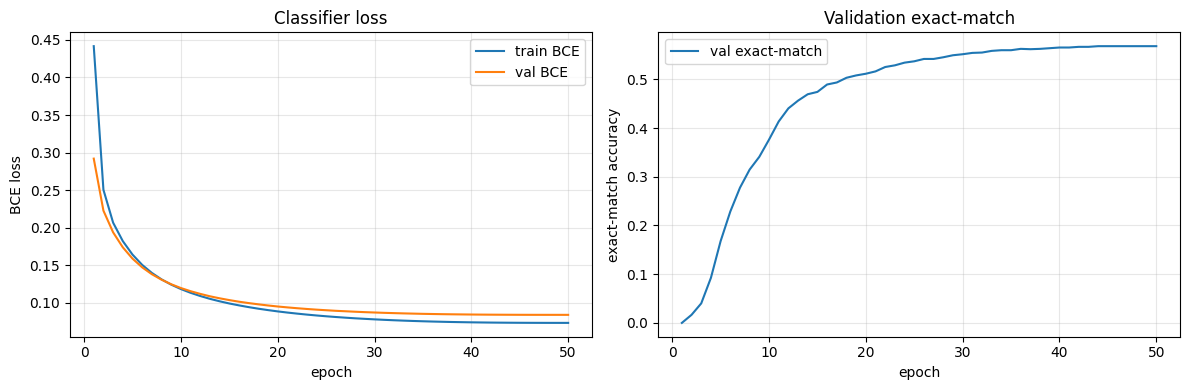

In [6]:
import matplotlib.pyplot as plt

epochs_axis = range(1, EPOCHS + 1)
fig, (ax_loss, ax_acc) = plt.subplots(1, 2, figsize=(12, 4))

ax_loss.plot(epochs_axis, history["train_loss"], label="train BCE") 
ax_loss.plot(epochs_axis, history["val_loss"],   label="val BCE")
ax_loss.set_xlabel("epoch"); ax_loss.set_ylabel("BCE loss")
ax_loss.set_title("Classifier loss")
ax_loss.legend(); ax_loss.grid(alpha=0.3)

ax_acc.plot(epochs_axis, history["val_exact"], label="val exact-match")
ax_acc.set_xlabel("epoch"); ax_acc.set_ylabel("exact-match accuracy")
ax_acc.set_title("Validation exact-match")
ax_acc.legend(); ax_acc.grid(alpha=0.3)

plt.tight_layout(); plt.show()

Based on the plots above, 50 training epochs are liekly enough as we are seeing the BCE-loss level starting to level out, and the train/val BCE slowly starting to diverge. 

As for the val exact-match, we see it starting to converge too. 

## CAM extraction

In [14]:
BG_THRESHOLD = 0.25

@torch.no_grad()
def compute_cams(patch_tokens: torch.Tensor, image_labels: torch.Tensor,
                 out_size: tuple[int, int]) -> torch.Tensor:
    """
    PSA-style CAM normalization: ReLU, then divide each (image, class) map by its
    own max only (no min subtraction), so a class that fires weakly stays weak.
    """
    classifier.eval()
    B = patch_tokens.shape[0]
    cams = classifier.cam(patch_tokens.float(), GRID)
    cams = F.relu(cams)
    cams = F.interpolate(cams, size=out_size, mode="bilinear", align_corners=False)

    cmax = cams.amax(dim=(2, 3), keepdim=True).clamp(min=1e-5)
    cams = cams / cmax

    mask = image_labels.view(B, NUM_CLASSES, 1, 1)
    return cams * mask


def cams_to_label_map(cams: torch.Tensor, bg_threshold: float = BG_THRESHOLD) -> torch.Tensor:
    """
    Argmax over classes to produce a label map in 0..C.
    """
    B, C, H, W = cams.shape
    bg = torch.full((B, 1, H, W), bg_threshold, device=cams.device, dtype=cams.dtype)
    full = torch.cat([bg, cams], dim=1)
    return full.argmax(dim=1)

## DenseCRF refinement

AffinityNet was one of the first methods to use CRF as an edge refinement technique. Using methods from their [codebase (CVPR 2018)](https://github.com/jiwoon-ahn/psa) we now apply it to our CAMs. 

In [15]:
import pydensecrf.densecrf as dcrf
from pydensecrf.utils import unary_from_softmax

IMAGENET_MEAN = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD  = np.array([0.229, 0.224, 0.225], dtype=np.float32)
CRF_ALPHA = 8

def crf_inference(img, probs, t=10, scale_factor=1, labels=21):
    """
    Copied from https://github.com/jiwoon-ahn/psa
    """
    h, w = img.shape[:2]
    n_labels = labels

    d = dcrf.DenseCRF2D(w, h, n_labels)

    rgbim = np.ascontiguousarray(img, dtype=np.uint8)
    unary = np.ascontiguousarray(unary_from_softmax(probs))

    d.setUnaryEnergy(unary)
    d.addPairwiseGaussian(sxy=3 / scale_factor, compat=3)
    d.addPairwiseBilateral(sxy=80 / scale_factor, srgb=13, rgbim=rgbim, compat=10)
    Q = d.inference(t)

    return np.array(Q).reshape((n_labels, h, w))


def _crf_with_alpha(orig_img, cam_dict, alpha):
    """
    Copied from https://github.com/jiwoon-ahn/psa
    """
    v = np.array(list(cam_dict.values()))
    bg_score = np.power(1 - np.max(v, axis=0, keepdims=True), alpha)
    bgcam_score = np.ascontiguousarray(np.concatenate((bg_score, v), axis=0),
                                       dtype=np.float32)
    crf_score = crf_inference(orig_img, bgcam_score, labels=bgcam_score.shape[0])

    n_crf_al = dict()
    n_crf_al[0] = crf_score[0]
    for i, key in enumerate(cam_dict.keys()):
        n_crf_al[key + 1] = crf_score[i + 1]
    return n_crf_al


def dense_crf(image_uint8: np.ndarray, cam: np.ndarray,
              alpha: float = CRF_ALPHA) -> np.ndarray:
    """
    Calling the CRF helpers
    """
    H, W = image_uint8.shape[:2]
    cam_dict = {c: cam[c] for c in range(cam.shape[0]) if cam[c].max() > 0}
    if not cam_dict:
        return np.zeros((H, W), dtype=np.int32)

    crf_dict = _crf_with_alpha(image_uint8, cam_dict, alpha)
    full = np.zeros((1 + cam.shape[0], H, W), dtype=np.float32)
    for k, v in crf_dict.items():
        full[k] = v
    return full.argmax(axis=0).astype(np.int32)



## Visualize CAMs and CRF refinement

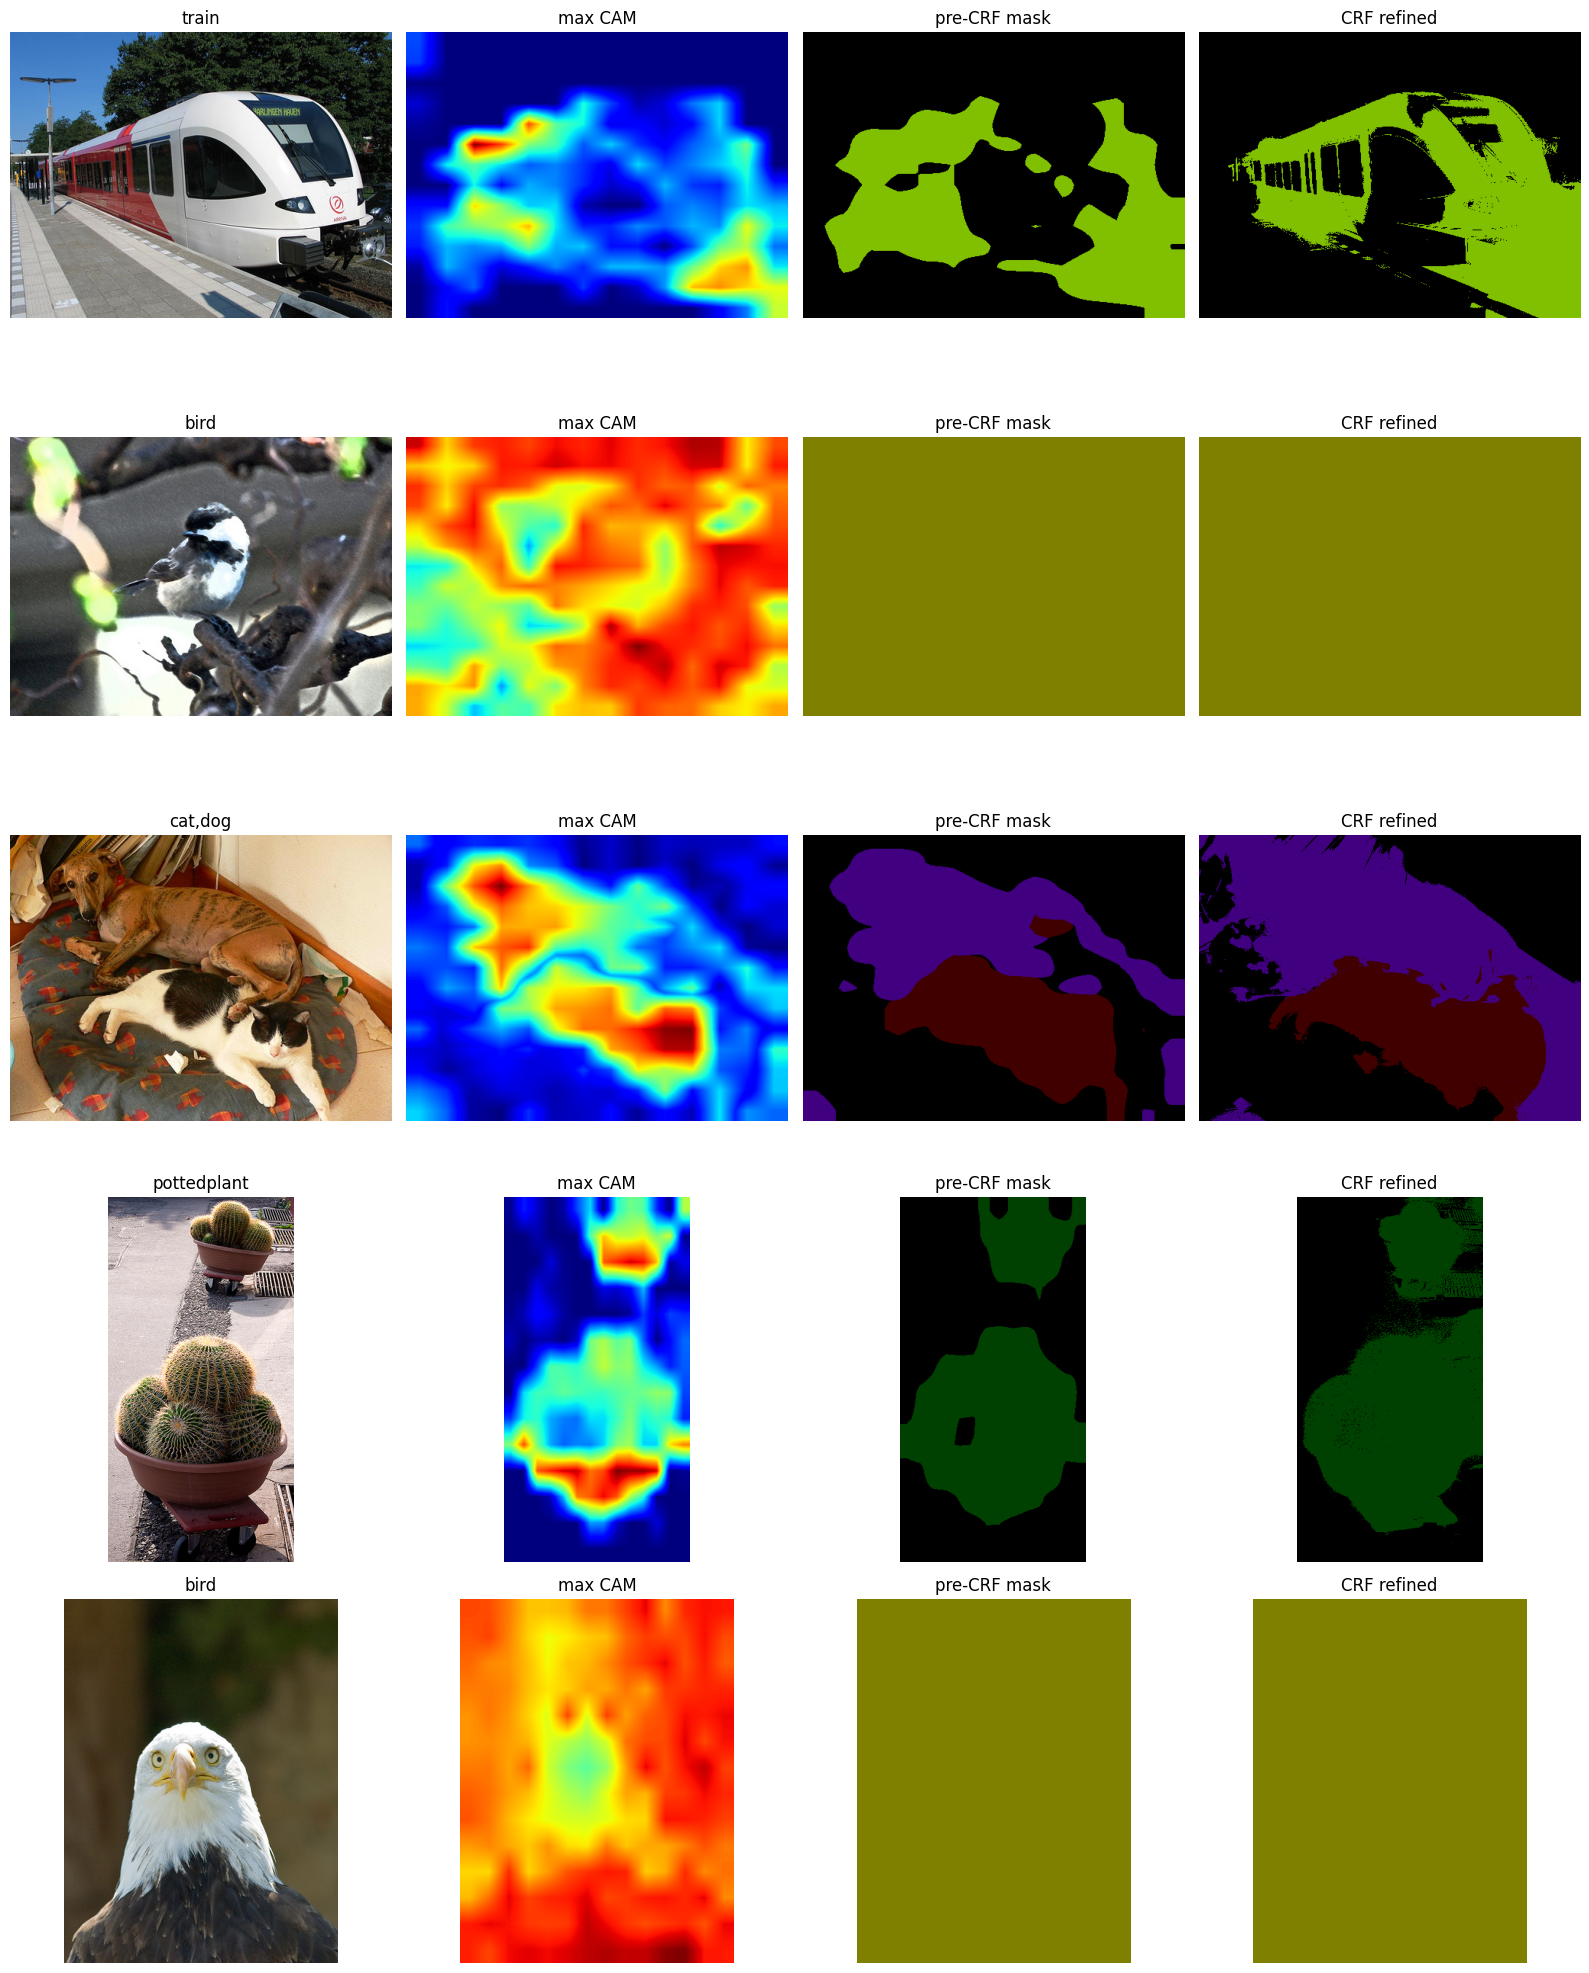

In [16]:
import matplotlib.pyplot as plt
import random


def visualize(num_images: int = 3, seed: int = 0):
    rng = random.Random(seed)
    indices = rng.sample(range(len(val_ds)), num_images)

    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4 * num_images))
    if num_images == 1:
        axes = [axes]

    for row, idx in zip(axes, indices):
        _, _, label_vec = val_ds[idx]
        label_batch = label_vec.unsqueeze(0).to(device)
        tokens = val_tokens[idx].unsqueeze(0).float()

        orig_img_pil, _ = val_ds.voc[idx]
        orig_img_uint8 = np.array(orig_img_pil.convert("RGB"))
        H, W = orig_img_uint8.shape[:2]

        cams = compute_cams(tokens, label_batch, out_size=(H, W))
        raw_labels = cams_to_label_map(cams)[0].cpu().numpy()
        crf_labels = dense_crf(orig_img_uint8, cams[0].cpu().numpy())

        present = [VOC_CLASSES[c] for c in torch.where(label_vec > 0)[0].tolist()]
        cam_vis = cams[0].max(dim=0).values.cpu().numpy()

        row[0].imshow(orig_img_uint8); row[0].set_title(",".join(present) or "(none)")
        row[1].imshow(cam_vis, cmap="jet", vmin=0, vmax=1); row[1].set_title("max CAM")
        row[2].imshow(colorize(raw_labels)); row[2].set_title("pre-CRF mask")
        row[3].imshow(colorize(crf_labels)); row[3].set_title("CRF refined")
        for ax in row:
            ax.axis("off")
    plt.tight_layout(); plt.show()


visualize(num_images=5)

## Validation mIoU

Score per-class IoU against ground-truth VOC masks for both for the raw CAM-argmax and the CRF-refined masks

In [10]:
def evaluate_miou(max_batches: int | None = None):
    n_cls = NUM_CLASSES + 1  # +1 background
    inter = np.zeros(n_cls, dtype=np.int64)
    union = np.zeros(n_cls, dtype=np.int64)

    loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True, collate_fn=wsss_collate_fn,
    )

    for b_idx, (indices, images, labels) in enumerate(tqdm(loader, desc="mIoU")):
        if max_batches is not None and b_idx >= max_batches:
            break
        labels = labels.to(device, non_blocking=True)
        tokens = val_tokens[indices].float()

        for i, ds_idx in enumerate(indices.tolist()):
            orig_img_pil, gt_pil = val_ds.voc[ds_idx]
            gt = np.array(gt_pil)
            H, W = gt.shape

            cam = compute_cams(
                tokens[i : i + 1], labels[i : i + 1], out_size=(H, W)
            )

            orig_img_uint8 = np.array(orig_img_pil.convert("RGB"))
            p = dense_crf(orig_img_uint8, cam[0].cpu().numpy())

            valid = gt != 255
            for c in range(n_cls):
                pc = (p == c) & valid
                tc = (gt == c) & valid
                inter[c] += np.logical_and(pc, tc).sum()
                union[c] += np.logical_or(pc, tc).sum()

    iou = inter / np.maximum(union, 1)
    present = union > 0
    miou = iou[present].mean()

    print(f"mIoU = {miou}")
    for c, name in enumerate(["background"] + VOC_CLASSES):
        if present[c]:
            print(f"  {name:<14s} {iou[c]:.4f}")
    return miou

evaluate_miou()

mIoU:   0%|          | 0/46 [00:00<?, ?it/s]

mIoU = 0.3666580311955941
  background     0.4416
  aeroplane      0.1515
  bicycle        0.2052
  bird           0.1371
  boat           0.1414
  bottle         0.4279
  bus            0.6226
  car            0.4030
  cat            0.5872
  chair          0.2054
  cow            0.5706
  diningtable    0.4787
  dog            0.3340
  horse          0.4230
  motorbike      0.4955
  person         0.4216
  pottedplant    0.3315
  sheep          0.3156
  sofa           0.4619
  train          0.3152
  tvmonitor      0.2295


np.float64(0.3666580311955941)

# Evaluation

The results are quite poor. That being said, based on the visualization cell, we believe this is because of the CAM generation rather than the CRF. This is because in the rows where the confidence overlapped with the truly correct regions, the CRF appeared to perform a cleaner segmentation. 